In [78]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')

In [79]:
skills_list = df['skills'].dropna().tolist()
all_skills = ",".join(skills_list).split(",")

In [80]:
from collections import Counter

skill_count = Counter(all_skills)

skills_df = pd.DataFrame(skill_count.items(), columns=['skill', 'count'])
skills_df.head()

,skill,count
0,Python,180
1,SQL,121
2,API,124
3,Git,77
4,AWS,84


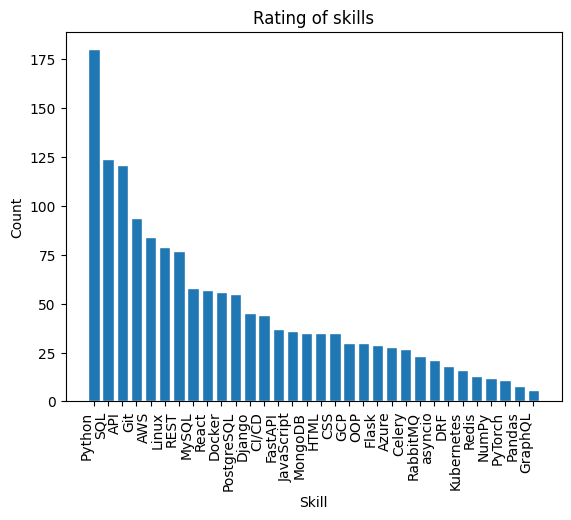

In [81]:
fig, ax = plt.subplots()

skills = skills_df['skill']
counts = skills_df['count'].sort_values(ascending=False)

ax.bar(skills, counts, edgecolor="white")

ax.set_title("Rating of skills")
ax.set_xlabel("Skill")
ax.set_ylabel("Count")
plt.xticks(rotation=90, ha='right')

plt.show()

In [82]:
df['skills'] = df['skills'].str.split(',')
exploded_df = df.explode("skills")
grouped = exploded_df.groupby(['skills', 'experience']).size().unstack(fill_value=0)
grouped.head()

experience,junior,middle,senior,trainee
skills,,,,
API,23,47,52,2
AWS,13,32,38,1
Azure,5,14,17,0
CI/CD,10,20,28,0
CSS,8,8,2,0


In [83]:
expo_map = {"trainee": 1, "junior": 2, "middle": 3, "senior": 4}
df['experience_mapping'] = df['experience'].map(expo_map)
df['num_skills'] = df['skills'].apply(lambda x: len(x) if isinstance(x, list) else 0)
correlation = df[["experience_mapping", "num_skills"]].corr()
correlation

,experience_mapping,num_skills
experience_mapping,1.000000,0.029825
num_skills,0.029825,1.000000
